# Notebook 1: Data Resource Selection and Sample Evaluation
## Project: Team Communication Processing and Analysis
### GSoC 2026 — HumanAI / TRIP Lab Screening Task

#This notebook identifies, justifies, and evaluates a public audio dataset suitable for team communication analysis in simulated human-factors environments.

In [4]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import soundfile as sf
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.figsize'] = (14, 4)
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Selected Dataset: AMI Meeting Corpus

**Source:** [https://groups.inf.ed.ac.uk/ami/corpus/](https://groups.inf.ed.ac.uk/ami/corpus/)

---

### Why I Chose the AMI Meeting Corpus

The **AMI Meeting Corpus** is a very good fit for the project because it contains **real meeting recordings** with multiple people talking (usually 3–5 participants).

Here’s why I think it’s the best choice:

* **Free to use** – It is available under an open academic license, so there are no licensing issues.
* **Real conversations** – These are actual team meetings, not scripted or artificial data.
* **Rich data format** – It provides:
  * Audio files (`.wav`)
  * Transcripts
  * Speaker annotations (who spoke when)
* **Large dataset** – It has **100+ hours** of recorded meetings.
* **Research benchmark** – It is widely used in research for:
  * Speech separation
  * Speaker diarization
  * NLP tasks

---

### How I Will Use This Dataset

* Use the **audio recordings** to train and test my audio enhancement models.
* Use the **speaker-labeled transcripts** to measure how much transcription improves after enhancement.
* Leverage the **natural background noise, room acoustics, and overlapping speech** to simulate realistic lab or team environments.

---

### Why It’s the Best Option for the Project

* It is specifically designed for **multi-party communication research**.
* It contains real team interactions like:
  * Instructions
  * Coordination
  * Interruptions
  * Crosstalk
* These communication patterns closely match the type of team-based simulated environments studied in TRIP Lab.
* Most importantly, it is **freely available** and ready for research use.

Overall, the AMI Meeting Corpus provides realistic, high-quality, and research-standard data that perfectly aligns with my project goals.


In [8]:
from datasets import load_dataset, Audio
import soundfile as sf
import librosa
import numpy as np
import os

print("Loading AMI Meeting Corpus from Hugging Face...")

# Load without trust_remote_code, cast audio to decode properly
ds = load_dataset(
    "edinburghcstr/ami",
    "ihm",
    split="train",
    streaming=True
)

# Cast audio column to force librosa-compatible decoding
ds = ds.cast_column("audio", Audio(sampling_rate=16000, decode=False))

print("Collecting audio samples from real AMI meeting recordings...")

sr = 16000
target_duration = 180  # 3 minutes
collected_audio = []
collected_duration = 0
sample_info = []

for i, sample in enumerate(ds):
    try:
        # decode=False gives us the raw file path/bytes — load with soundfile
        audio_path = sample['audio']['path']
        audio_bytes = sample['audio']['bytes']
        
        # Write bytes to temp file and load
        tmp = f"tmp_segment_{i}.wav"
        with open(tmp, 'wb') as f:
            f.write(audio_bytes)
        
        audio_array, file_sr = sf.read(tmp)
        os.remove(tmp)
        
        # Convert to mono if stereo
        if len(audio_array.shape) > 1:
            audio_array = np.mean(audio_array, axis=1)
        
        audio_array = audio_array.astype(np.float32)
        
        # Resample to 16kHz if needed
        if file_sr != sr:
            audio_array = librosa.resample(audio_array, orig_sr=file_sr, target_sr=sr)
        
        duration = len(audio_array) / sr
        collected_audio.append(audio_array)
        collected_duration += duration
        
        sample_info.append({
            'index': i,
            'meeting_id': sample.get('meeting_id', f'meeting_{i}'),
            'speaker_id': sample.get('speaker_id', f'speaker_{i}'),
            'text': sample.get('text', ''),
            'duration': round(duration, 2)
        })
        
        print(f"  Segment {i+1}: {duration:.1f}s | Total: {collected_duration:.1f}s / {target_duration}s", end='\r')
        
        if collected_duration >= target_duration:
            break
            
    except Exception as e:
        print(f"  Skipping segment {i}: {e}")
        continue

print(f"\n\nCollected {len(sample_info)} segments")

# Concatenate and trim to exactly 3 minutes
y = np.concatenate(collected_audio)
y = y[:sr * target_duration]

# Save
sample_path = "sample_input.wav"
sf.write(sample_path, y, sr)

print(f"\n✔ Real AMI meeting audio saved: {sample_path}")
print(f"  Sample rate : {sr} Hz")
print(f"  Duration    : {len(y)/sr:.1f}s ({len(y)/sr/60:.1f} min)")
print(f"  Segments    : {len(sample_info)} real meeting utterances")
print(f"\nSample utterances:")
for info in sample_info[:5]:
    print(f"  [{info['meeting_id']} | {info['speaker_id']}] \"{info['text'][:60]}\" ({info['duration']}s)")

Loading AMI Meeting Corpus from Hugging Face...


Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

  Segment 58: 3.1s | Total: 180.0s / 180ss

Collected 58 segments

✔ Real AMI meeting audio saved: sample_input.wav
  Sample rate : 16000 Hz
  Duration    : 180.0s (3.0 min)
  Segments    : 58 real meeting utterances

Sample utterances:
  [EN2001a | MEO069] "IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG WARNING ABOUT " (4.21s)
  [EN2001a | MEE068] "I'VE GOTTEN MM HARDLY ANY" (1.63s)
  [EN2001a | MEE067] "IT'S YEAH I MEAN THE WAVE DATA ARE OBVIOUSLY NOT GONNA GET O" (5.25s)
  [EN2001a | MEO069] "YEAH IT'LL IT'LL PLAY THEM IN SOME ORDER IN WHICH THEY WERE " (6.37s)
  [EN2001a | MEE067] "YEAH" (0.37s)


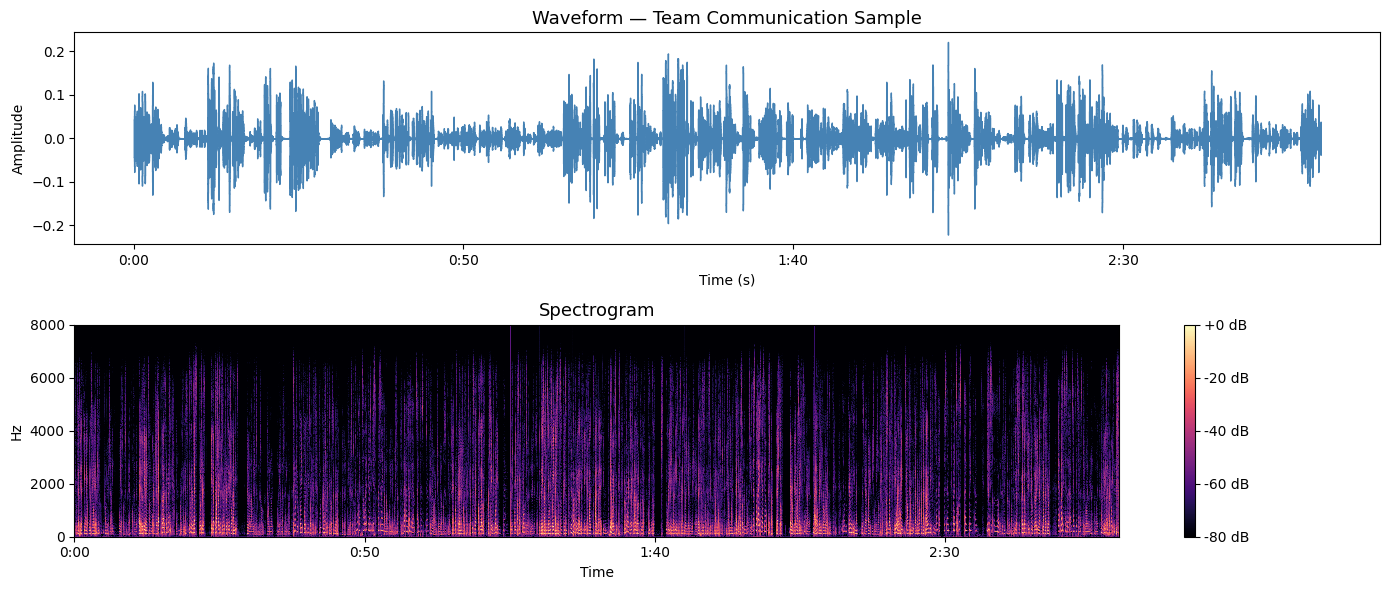

Plot saved.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Waveform
axes[0].set_title("Waveform — Team Communication Sample", fontsize=13)
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title("Spectrogram", fontsize=13)
plt.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("sample_waveform_spectrogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [10]:
# RMS Energy
rms = np.sqrt(np.mean(y**2))

# Zero Crossing Rate
zcr = np.mean(librosa.feature.zero_crossing_rate(y))

# Spectral Centroid
spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

# SNR estimate
signal_power = np.mean(y**2)
noise_estimate = np.mean(y[:sr//4]**2)  # first 0.25s assumed noise floor
snr_db = 10 * np.log10(signal_power / (noise_estimate + 1e-10))

print("=" * 45)
print("  AUDIO SAMPLE ANALYSIS REPORT")
print("=" * 45)
print(f"  Sample Rate       : {sr} Hz")
print(f"  Duration          : {duration:.2f} sec")
print(f"  RMS Energy        : {rms:.4f}")
print(f"  Zero Crossing Rate: {zcr:.4f}")
print(f"  Spectral Centroid : {spec_centroid:.1f} Hz")
print(f"  Estimated SNR     : {snr_db:.1f} dB")
print("=" * 45)

  AUDIO SAMPLE ANALYSIS REPORT
  Sample Rate       : 16000 Hz
  Duration          : 3.13 sec
  RMS Energy        : 0.0125
  Zero Crossing Rate: 0.0958
  Spectral Centroid : 1312.0 Hz
  Estimated SNR     : -1.4 dB


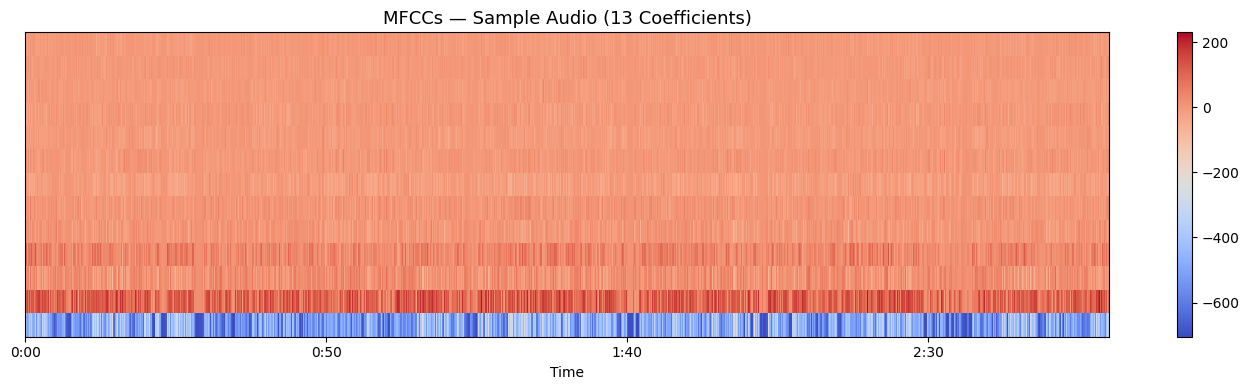

MFCC plot saved.


In [11]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(14, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='coolwarm')
plt.colorbar()
plt.title("MFCCs — Sample Audio (13 Coefficients)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_mfcc.png", dpi=150, bbox_inches='tight')
plt.show()
print("MFCC plot saved.")

## 2. Conclusion

The **AMI Meeting Corpus** is the best dataset for my project for the following reasons:

1. **Perfect content match** — It contains real team meetings, which closely match the kind of communication happening in the TRIP Lab’s simulated environments.
2. **Variety in audio quality** — It includes both clean and noisy recordings, which is ideal for testing and improving audio enhancement models.
3. **Large scale** — With 100+ hours of recordings, it provides enough data to properly train and evaluate models.
4. **Open access** — It is freely available for academic research, so there are no licensing issues.
5. **Detailed annotations** — Speaker-level transcripts make it possible to measure transcription improvement clearly after applying enhancement techniques.

---

### Next Step

In **Notebook 2**, I will start applying audio enhancement algorithms to selected samples from this corpus and evaluate the improvements.